# Ego Zone Tuner

Extract a frame from your dashcam video and draw the ego-zone trapezoid on it.
Adjust the parameters and re-run the **Draw** cell.

**Workflow:**
1. Run **Extract frame** to grab a frame from your video.
2. Run **Draw** to see the current trapezoid.
3. Tweak **Parameters** and re-run **Draw**.
4. Copy values into `ego_vision/config/settings.py`.

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (16, 9)

## 1. Extract frame

Change `VIDEO_PATH` and `FRAME_INDEX`.

In [22]:
VIDEO_PATH = "../data/video.mp4"   # <-- change to your video file
FRAME_INDEX = 0                     # which frame to grab (0 = first)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {VIDEO_PATH}")

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INDEX)
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read frame {FRAME_INDEX} from {VIDEO_PATH}")

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
H, W = frame_rgb.shape[:2]
print(f"Frame {FRAME_INDEX}: {W}x{H}")

Frame 0: 1280x720


## 2. Parameters

All values are **normalized** (0.0 – 1.0) relative to frame dimensions.

| Parameter | What it controls |
|---|---|
| `CENTER` | Horizontal center (0.5 = middle of frame) |
| `Y_TOP` | Top edge Y — **smaller = higher toward horizon** |
| `Y_BOTTOM` | Bottom edge Y — **at the bonnet edge where street starts** |
| `BOTTOM_WIDTH` | Bottom edge width (wide = close to car) |
| `TOP_WIDTH` | Top edge width (narrow = far away) |

**Tip:** `Y_BOTTOM` should be at the end of the bonnet, not the windshield.
Start with `Y_BOTTOM = 0.95` and `Y_TOP = 0.55`, then adjust.

In [35]:
CENTER       = 0.50   # horizontal center of trapezoid
Y_TOP        = 0.60   # top edge Y (smaller = reaches higher toward horizon)
Y_BOTTOM     = 0.73   # bottom edge Y (at bonnet edge where street starts)
BOTTOM_WIDTH = 0.32   # bottom edge width (wide)
TOP_WIDTH    = 0.06   # top edge width (narrow)

## 3. Draw

Re-run this cell after changing parameters.

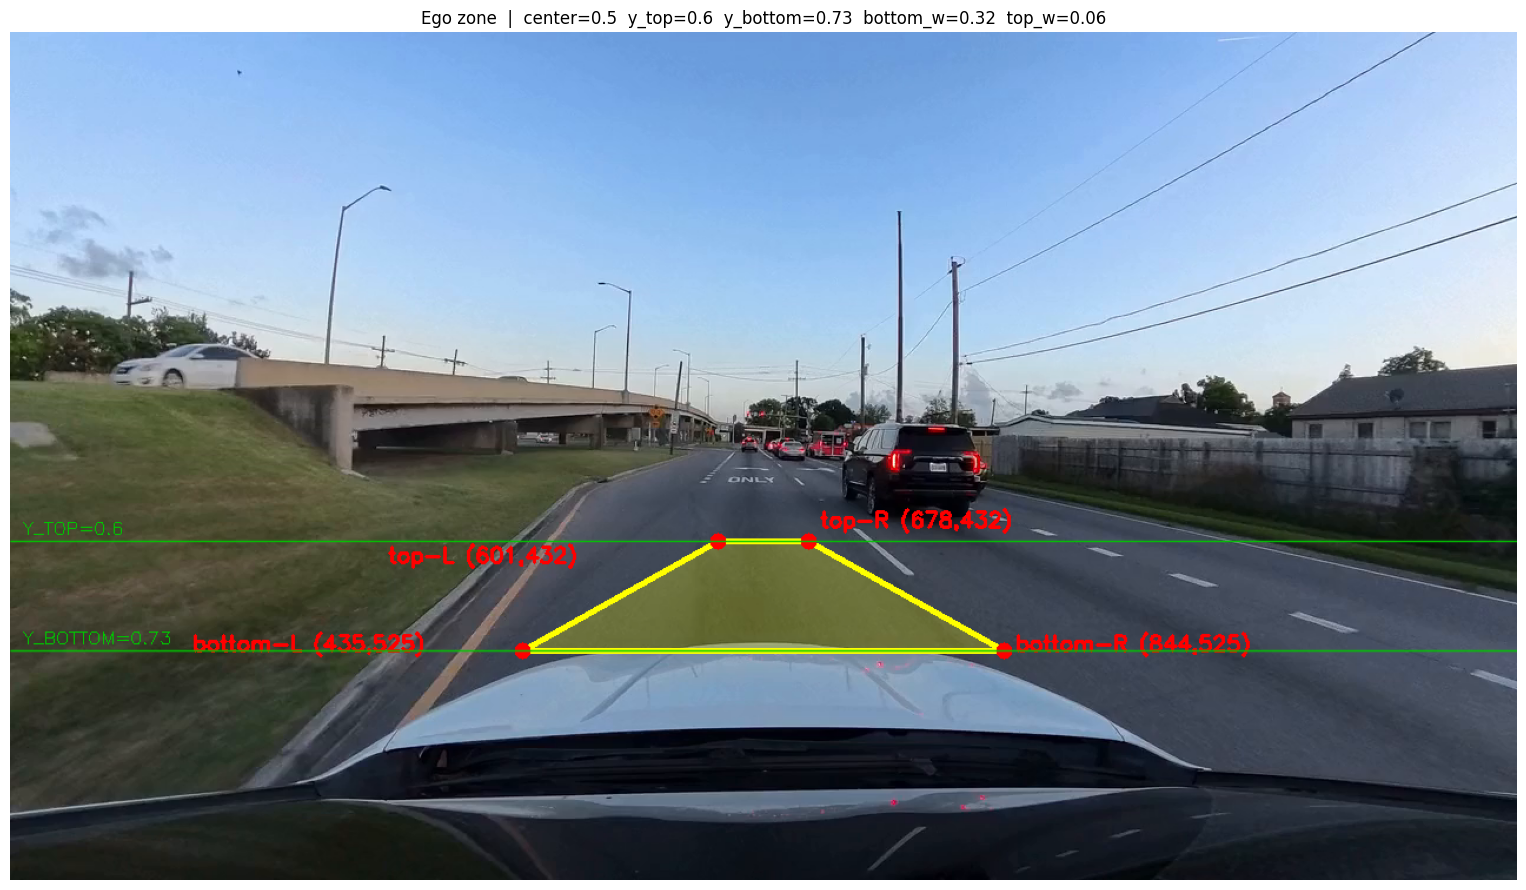

In [36]:
bw = BOTTOM_WIDTH / 2.0
tw = TOP_WIDTH / 2.0
pts_norm = [
    (CENTER - bw, Y_BOTTOM),
    (CENTER + bw, Y_BOTTOM),
    (CENTER + tw, Y_TOP),
    (CENTER - tw, Y_TOP),
]
pts = np.array(pts_norm, dtype=np.float64)
pts_px = (pts * [W, H]).astype(np.int32)

# Draw on a copy
vis = frame_rgb.copy()

# Filled trapezoid (semi-transparent)
overlay = vis.copy()
cv2.fillPoly(overlay, [pts_px], (255, 255, 0))
cv2.addWeighted(overlay, 0.25, vis, 0.75, 0, vis)

# Border
cv2.polylines(vis, [pts_px], isClosed=True, color=(255, 255, 0), thickness=3)

# Corner dots + labels (offsets to avoid overlap)
labels = ["bottom-L", "bottom-R", "top-R", "top-L"]
x_off = [-280, 10, 10, -280]
y_off = [0, 0, -12, 18]
for (x, y), label, xo, yo in zip(pts_px, labels, x_off, y_off):
    cv2.circle(vis, (int(x), int(y)), 7, (255, 0, 0), -1)
    cv2.putText(vis, f"{label} ({x},{y})",
                (int(x) + xo, int(y) + yo),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Horizontal reference lines
cv2.line(vis, (0, int(Y_TOP * H)), (W, int(Y_TOP * H)), (0, 200, 0), 1, cv2.LINE_AA)
cv2.line(vis, (0, int(Y_BOTTOM * H)), (W, int(Y_BOTTOM * H)), (0, 200, 0), 1, cv2.LINE_AA)
cv2.putText(vis, f"Y_TOP={Y_TOP}", (10, int(Y_TOP * H) - 6),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 1)
cv2.putText(vis, f"Y_BOTTOM={Y_BOTTOM}", (10, int(Y_BOTTOM * H) - 6),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 1)

# Show
plt.imshow(vis)
plt.title(f"Ego zone  |  center={CENTER}  y_top={Y_TOP}  y_bottom={Y_BOTTOM}  "
          f"bottom_w={BOTTOM_WIDTH}  top_w={TOP_WIDTH}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Copy values to settings.py

Once you're happy with the trapezoid, update `ego_vision/config/settings.py`:

```python
EGO_ZONE_CENTER       = CENTER
EGO_ZONE_TOP_Y        = Y_TOP
EGO_ZONE_BOTTOM_Y     = Y_BOTTOM
EGO_ZONE_BOTTOM_WIDTH = BOTTOM_WIDTH
EGO_ZONE_TOP_WIDTH    = TOP_WIDTH
```